# Customer Churn Prediction Platform
## Notebook 2 of 4: Feature Engineering

**Author:** Lauren Beeler   
**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) via Kaggle

## Overview

This notebook takes the clean customer table from notebook 1 and prepares the feature matrix the model will learn from. Because the Telco dataset already lives at the customer level (one row per customer), there is no aggregation to perform. The work here is encoding the categorical columns into a format the model can use, noting a multicollinearity issue between three of the numerical features, exploring how each feature relates to churn, and producing a clean numerical feature matrix.

The features fall into four groups:

1. **Account features** -- How long the customer has been with the company (tenure), what kind of contract they have, how much they pay per month, and their total spend. These are the behavioral and financial signals most directly tied to churn risk.

2. **Service features** -- Which services the customer is subscribed to (internet, phone, streaming, security, backup, tech support). Customers who are more deeply embedded in the product tend to churn less.

3. **Demographic features** -- Gender, senior citizen status, whether they have a partner or dependents. These are weaker signals on their own but can interact with service and account features.

4. **Billing features** -- Payment method and paperless billing status.

The churn label already exists in the dataset as a binary column. No time-based label construction is needed here. 

### Project Notebooks
- 01_data_wrangling.ipynb
- **02_feature_engineering.ipynb** -- you are here
- 03_modeling.ipynb
- 04_shap_explainability.ipynb

### What this notebook produces
A customer-level feature matrix with a churn label, saved to `data/customer_features.csv`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

INPUT_PATH  = '../data/telco_clean.csv'
OUTPUT_PATH = '../data/customer_features.csv'

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Clean Data

In [2]:
df = pd.read_csv(INPUT_PATH)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print(df.head())

Loaded: 7,032 rows x 21 columns

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0    

## 3. Note on Multicollinearity

`TotalCharges`, `tenure`, and `MonthlyCharges` are related but not as tightly as they might first appear. A check in notebook 1 showed that TotalCharges does not simply equal tenure multiplied by monthly charges. Over 2,300 customers had a discrepancy larger than $50, because monthly charges shift over time as customers add or drop services. That said, the three features still carry overlapping information and some degree of multicollinearity is expected. For XGBoost this is not a major concern since tree-based models handle correlated features decently well. For logistic regression it could cause issues, since multicollinearity can inflate coefficient variance and make individual coefficients harder to interpret.

All three are kept in the model because each captures a different aspect of customer value: tenure measures how long someone has been a customer, monthly charges reflects their current spend level, and total charges captures their actual cumulative billing history. The correlation matrix in section 6 will show exactly how closely they track each other.

## 4. Encode Categorical Features

Machine learning models work with numbers, not strings. The categorical columns in this dataset need to be converted to numeric representations before modeling.

Two encoding approaches are used here:

- **Binary columns** (Yes/No) are mapped to 1/0 directly. This applies to columns like `PhoneService`, `PaperlessBilling`, and the various service add-ons.
- **Multi-category columns** (anything with more than two options) get one-hot encoded using `pd.get_dummies`. This creates one new binary column per category and avoids imposing an artificial ordering on the values. `drop_first=True` removes one category per column to avoid multicollinearity.

Two Notes: 
- `SeniorCitizen` is already stored as 0/1 integers in the raw dataset, not as Yes/No strings like the other columns. It does not need encoding and is intentionally left out of the binary mapping below.
- Several service columns (`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) have three possible values: Yes, No, and No internet service or No phone service. Mapping all non-Yes values to 0 treats both No and No internet service as the same thing, the customer does not have the feature. This is a deliberate simplification: what matters for churn is whether the customer is using the service, not the specific reason they are not.

The `customerID` column is set as the index instead of dropping it, so it can still be used to look up a specific customer in the Streamlit app later, without the model ever seeing it as a feature to learn from. 

In [3]:
# set customerID as the index 
df = df.set_index('customerID')

# binary yes/no columns: map directly to 1/0
# SeniorCitizen is intentionally excluded, it is already stored as 0/1
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# all non-Yes values map to 0, including 'No internet service' and 'No phone service'
# this treats the question as binary: does the customer have this feature or not
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)

# gender: Female = 1, Male = 0
df['gender'] = (df['gender'] == 'Female').astype(int)

print('Binary encoding done.')
print()
print('SeniorCitizen (already 0/1, not re-encoded):')
print(df['SeniorCitizen'].value_counts())
print()
print('Sample of binary-encoded columns:')
print(df[['gender', 'Partner', 'PhoneService', 'OnlineSecurity']].head())

Binary encoding done.

SeniorCitizen (already 0/1, not re-encoded):
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Sample of binary-encoded columns:
            gender  Partner  PhoneService  OnlineSecurity
customerID                                               
7590-VHVEG       0        1             0               0
5575-GNVDE       0        0             1               1
3668-QPYBK       0        0             1               1
7795-CFOCW       0        0             0               1
9237-HQITU       0        0             1               0


In [4]:
# multi-category columns: one-hot encode
# InternetService: DSL / Fiber optic / No
# Contract: Month-to-month / One year / Two year
# PaymentMethod: four options

multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# convert any boolean columns created by get_dummies to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Shape after encoding: {df.shape}')
print()
print('All columns:')
for col in df.columns:
    print(f'  {col}')

Shape after encoding: (7032, 24)

All columns:
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  Churn
  InternetService_Fiber optic
  InternetService_No
  Contract_One year
  Contract_Two year
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check


## 5. Verify No Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values. Feature matrix is complete.')
else:
    print('Missing values found:')
    print(missing)

No missing values. Feature matrix is complete.


## 6. Explore Feature Relationships with Churn

A quick look at how each feature differs between churned and retained customers. If the features are meaningful, we should see clear separation between the two groups.

In [6]:
churned  = df[df['Churn'] == 1]
retained = df[df['Churn'] == 0]

print(f'Churned customers:  {len(churned):,} ({len(churned)/len(df)*100:.1f}%)')
print(f'Retained customers: {len(retained):,} ({len(retained)/len(df)*100:.1f}%)')
print()

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print('Numeric feature means by churn status:')
print(df.groupby('Churn')[numeric_features].mean().round(2).T)

Churned customers:  1,869 (26.6%)
Retained customers: 5,163 (73.4%)

Numeric feature means by churn status:
Churn                0       1
tenure           37.65   17.98
MonthlyCharges   61.31   74.44
TotalCharges   2555.34 1531.80


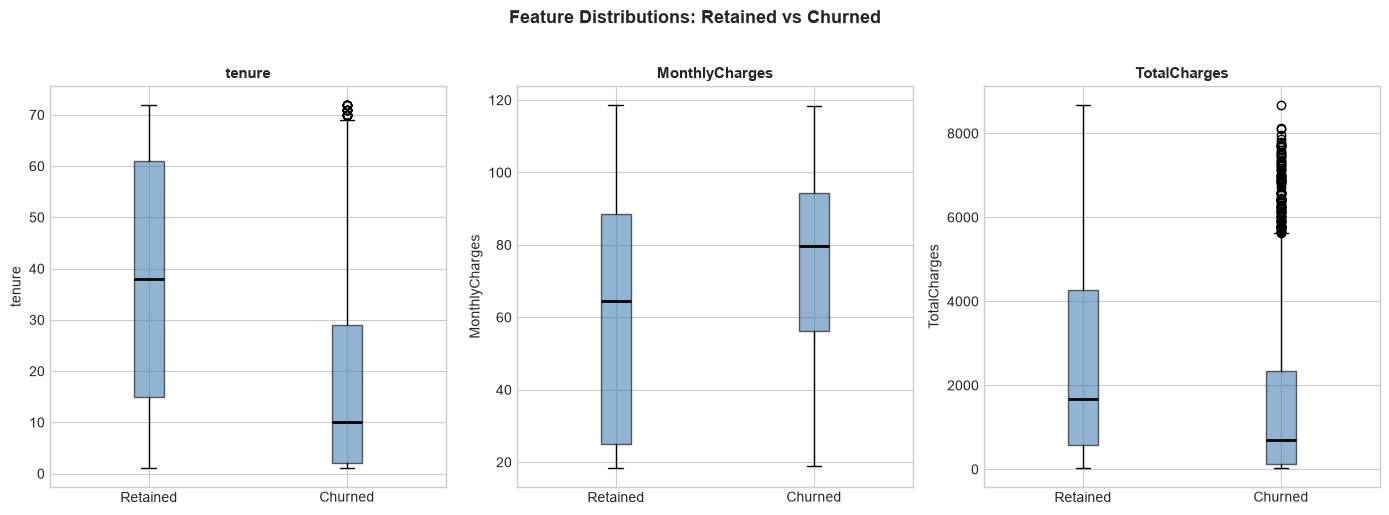

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, numeric_features):
    churned_vals  = df[df['Churn'] == 1][col]
    retained_vals = df[df['Churn'] == 0][col]

    ax.boxplot([retained_vals, churned_vals],
               tick_labels=['Retained', 'Churned'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Feature Distributions: Retained vs Churned',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# churn rates for key categorical features after encoding
print('Churn rates for selected features:')
print()
print(f'  Senior citizen:    {df[df["SeniorCitizen"]==1]["Churn"].mean()*100:.1f}% vs {df[df["SeniorCitizen"]==0]["Churn"].mean()*100:.1f}% (non-senior)')
print(f'  Has partner:       {df[df["Partner"]==1]["Churn"].mean()*100:.1f}% vs {df[df["Partner"]==0]["Churn"].mean()*100:.1f}% (no partner)')
print(f'  Has phone service: {df[df["PhoneService"]==1]["Churn"].mean()*100:.1f}% vs {df[df["PhoneService"]==0]["Churn"].mean()*100:.1f}% (no phone)')
print(f'  Online security:   {df[df["OnlineSecurity"]==1]["Churn"].mean()*100:.1f}% vs {df[df["OnlineSecurity"]==0]["Churn"].mean()*100:.1f}% (no security)')
print(f'  Tech support:      {df[df["TechSupport"]==1]["Churn"].mean()*100:.1f}% vs {df[df["TechSupport"]==0]["Churn"].mean()*100:.1f}% (no support)')
print(f'  Two year contract: {df[df["Contract_Two year"]==1]["Churn"].mean()*100:.1f}% vs {df[df["Contract_Two year"]==0]["Churn"].mean()*100:.1f}% (not two year)')

Churn rates for selected features:

  Senior citizen:    41.7% vs 23.7% (non-senior)
  Has partner:       19.7% vs 33.0% (no partner)
  Has phone service: 26.7% vs 25.0% (no phone)
  Online security:   14.6% vs 31.4% (no security)
  Tech support:      15.2% vs 31.2% (no support)
  Two year contract: 2.8% vs 34.1% (not two year)


## 7. Correlation Matrix

A correlation matrix shows how strongly each feature is linearly related to every other feature, and to the churn label. This is a standard EDA step that helps confirm which features are actually carrying signal before handing the data to a model.

Two things to look for: the correlation between tenure, MonthlyCharges, and TotalCharges (which the multicollinearity note in section 3 covers in more detail), and how spread the signal is across features. Unlike the Olist data this project originally used, where recency alone accounted for nearly all predictive signal, the correlations here are distributed across tenure, contract type, internet service, and payment method, which means the model has diverse features to learn from.

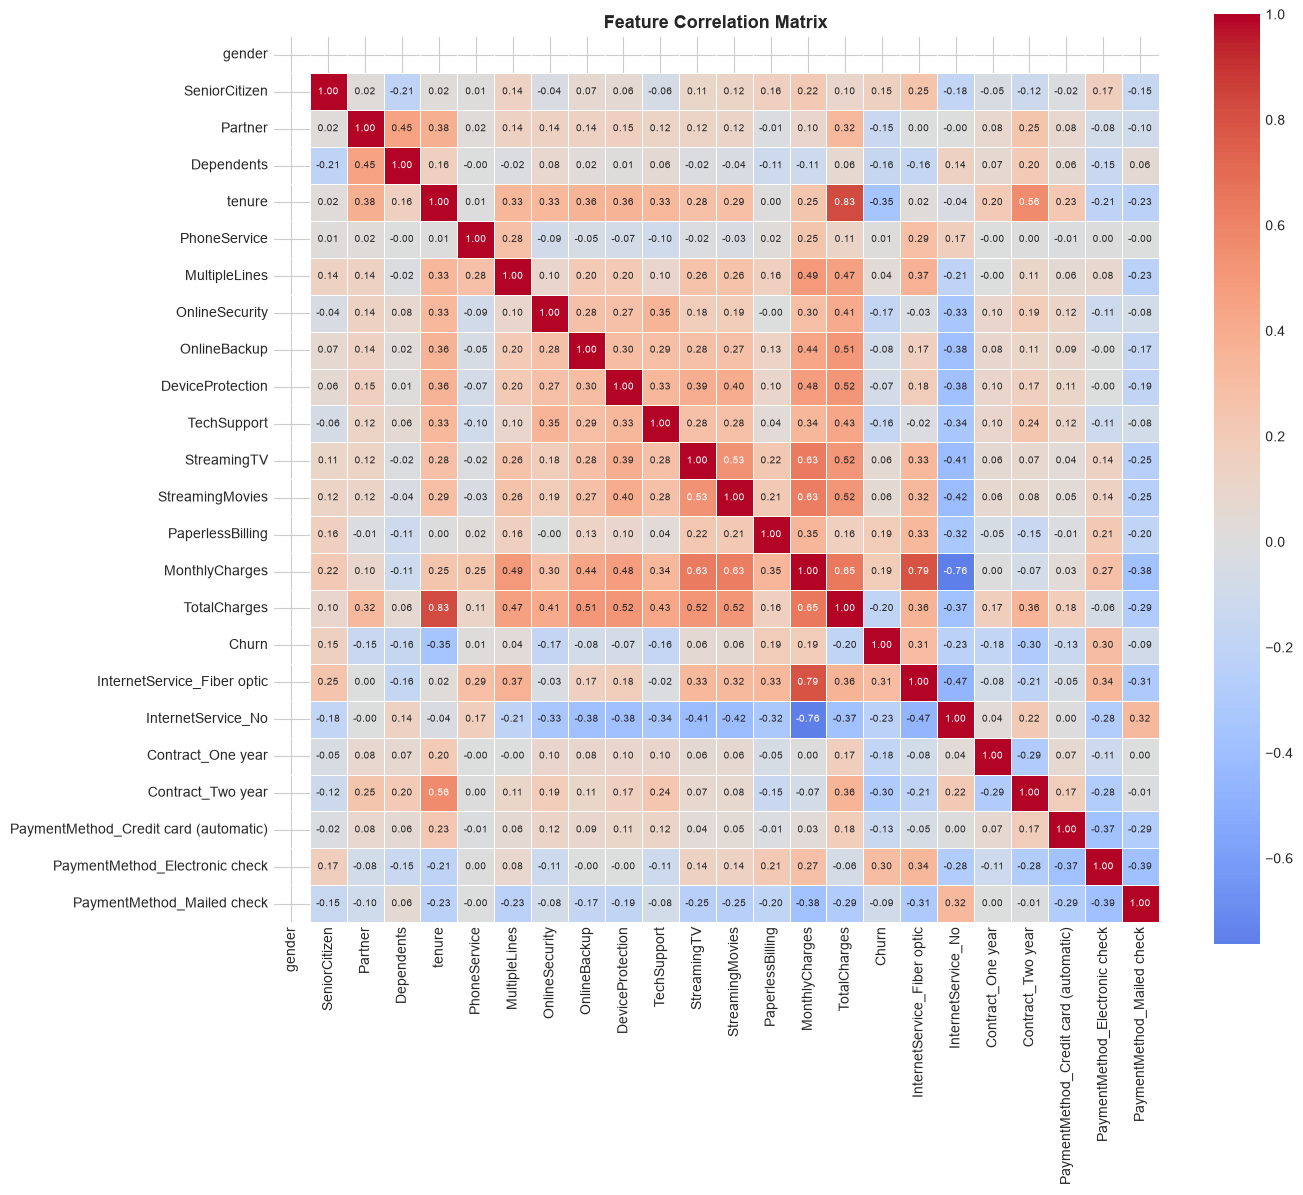

Correlations with churn label (sorted by strength):
  tenure: -0.354
  InternetService_Fiber optic: +0.307
  Contract_Two year: -0.302
  PaymentMethod_Electronic check: +0.301
  InternetService_No: -0.228
  TotalCharges: -0.199
  MonthlyCharges: +0.193
  PaperlessBilling: +0.191
  Contract_One year: -0.178
  OnlineSecurity: -0.171

Correlation between TotalCharges, tenure, and MonthlyCharges (multicollinearity check):
                TotalCharges  tenure  MonthlyCharges
TotalCharges            1.00    0.83            0.65
tenure                  0.83    1.00            0.25
MonthlyCharges          0.65    0.25            1.00


In [9]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# print correlations with churn specifically, sorted by absolute value
print('Correlations with churn label (sorted by strength):')
churn_corr = corr_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)
for feature, val in churn_corr.head(10).items():
    direction = '+' if corr_matrix['Churn'][feature] > 0 else '-'
    print(f'  {feature}: {direction}{val:.3f}')

print()
print('Correlation between TotalCharges, tenure, and MonthlyCharges (multicollinearity check):')
print(df[['TotalCharges', 'tenure', 'MonthlyCharges']].corr().round(3))

## 8. Assemble the Final Feature Matrix

Separating the churn label from the features and confirming the final shape before saving. The `Churn` column becomes the target variable `y` in the modeling notebook; everything else is a feature.

In [10]:
print(f'Feature matrix shape: {df.shape}')
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')
print()
print('All columns (Churn is the target variable, everything else is a feature):')
for col in df.columns:
    marker = ' <-- target' if col == 'Churn' else ''
    print(f'  {col}{marker}')

Feature matrix shape: (7032, 24)
Churn rate: 26.6%

All columns (Churn is the target variable, everything else is a feature):
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  Churn <-- target
  InternetService_Fiber optic
  InternetService_No
  Contract_One year
  Contract_Two year
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check


## 9. Save

Saving the feature matrix so the modeling notebook can load it directly.

In [11]:
df.to_csv(OUTPUT_PATH)

print(f'Saved to: {OUTPUT_PATH}')
print(f'Final shape: {df.shape}')
print()
print('Next: 03_modeling.ipynb')

Saved to: ../data/customer_features.csv
Final shape: (7032, 24)

Next: 03_modeling.ipynb


## Summary

| Step | Result |
|------|--------|
| Loaded clean data | 7,032 customers x 21 columns (24 after encoding) |
| Noted multicollinearity | TotalCharges, tenure, and MonthlyCharges are correlated -- kept all three with documentation |
| Set customerID as index | Kept for customer lookup in the app, excluded from model features |
| Binary encoded Yes/No columns | 12 columns mapped to 1/0, SeniorCitizen left as-is (already 0/1) |
| Noted three-value service columns | No internet service and No mapped to same 0 value -- deliberate simplification |
| One-hot encoded multi-category columns | InternetService, Contract, PaymentMethod |
| Verified no missing values | Feature matrix is complete |
| Explored feature relationships | Tenure, contract type, internet service type, and payment method all show meaningful churn signal |
| Saved customer_features.csv | Model-ready feature matrix |

**Next notebook:** `03_modeling.ipynb` -- train XGBoost and logistic regression, evaluate performance, and compare the two models.